In [244]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [245]:
df = pd.read_csv('Demand.csv')

In [246]:
df

,Region,Balanced_Credit_Amount,Location,Age,Size,Promotion,Holidays,Order_Quantity
0,East,12,Urban,6,2,0,1,0
1,East,12,Urban,3,2,0,1,0
2,East,24,Urban,5,2,0,1,0
3,South,24,Urban,18,2,0,1,0
4,South,45,Urban,21,3,0,1,0
...,...,...,...,...,...,...,...,...
995,South,16,Semi-Urban,15,50,1,3,7500
996,South,10,Urban,25,52,1,1,13000
997,South,9,Rural,1,56,1,1,0
998,North,6,Semi-Urban,4,56,1,3,2240


# EDA

In [247]:
df.shape

(1000, 8)

In [248]:
df.head()

,Region,Balanced_Credit_Amount,Location,Age,Size,Promotion,Holidays,Order_Quantity
0,East,12,Urban,6,2,0,1,0
1,East,12,Urban,3,2,0,1,0
2,East,24,Urban,5,2,0,1,0
3,South,24,Urban,18,2,0,1,0
4,South,45,Urban,21,3,0,1,0


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Region                  1000 non-null   object
 1   Balanced_Credit_Amount  1000 non-null   int64 
 2   Location                1000 non-null   object
 3   Age                     1000 non-null   int64 
 4   Size                    1000 non-null   int64 
 5   Promotion               1000 non-null   int64 
 6   Holidays                1000 non-null   int64 
 7   Order_Quantity          1000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 62.6+ KB


In [250]:
df.describe()

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,12.982000,17.546000,0.643000,1.407000,2281.810000
std,12.058814,7.193012,11.375469,0.479355,0.577654,2844.058806
min,4.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,12.000000,7.000000,9.000000,0.000000,1.000000,117.500000
50%,18.000000,13.000000,15.000000,1.000000,1.000000,1200.000000
75%,24.000000,19.000000,24.000000,1.000000,2.000000,3200.000000
max,72.000000,25.000000,57.000000,1.000000,4.000000,13440.000000


In [251]:
df.isnull().sum()

Region                    0
Balanced_Credit_Amount    0
Location                  0
Age                       0
Size                      0
Promotion                 0
Holidays                  0
Order_Quantity            0
dtype: int64

In [252]:
df.columns

Index(['Region', 'Balanced_Credit_Amount', 'Location', 'Age', 'Size',
       'Promotion', 'Holidays', 'Order_Quantity'],
      dtype='object')

In [253]:
numeric_columns = ['Balanced_Credit_Amount', 'Age', 'Size', 'Promotion', 'Holidays', 'Order_Quantity']

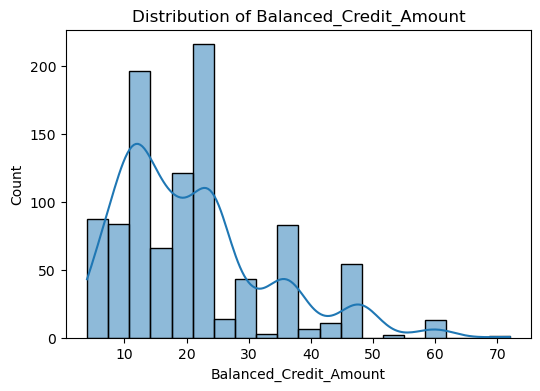

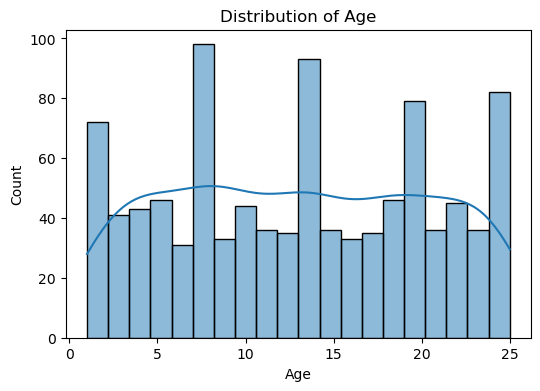

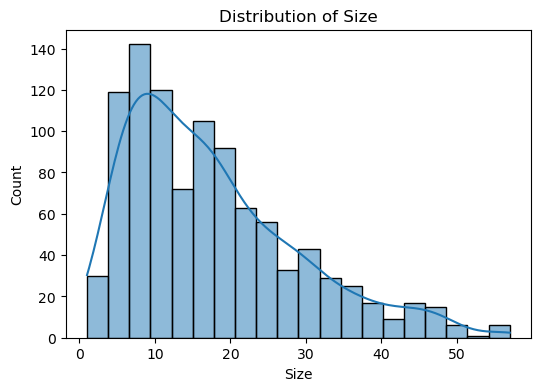

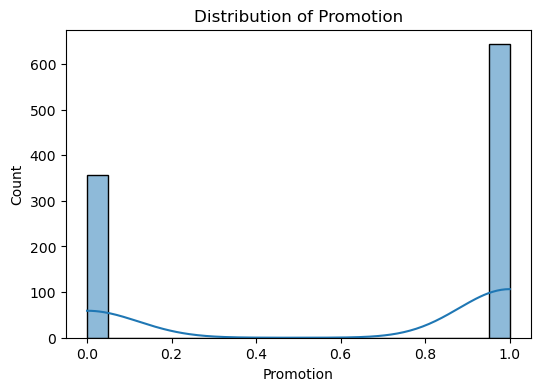

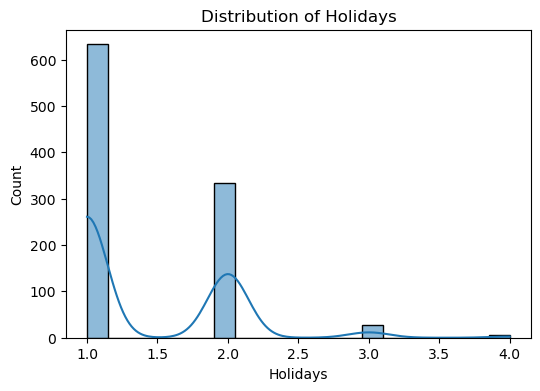

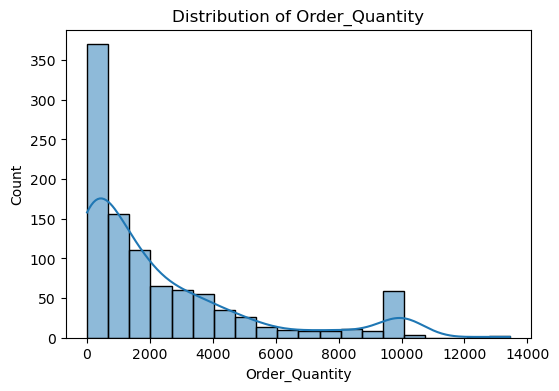

In [254]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

<Axes: xlabel='Region', ylabel='count'>

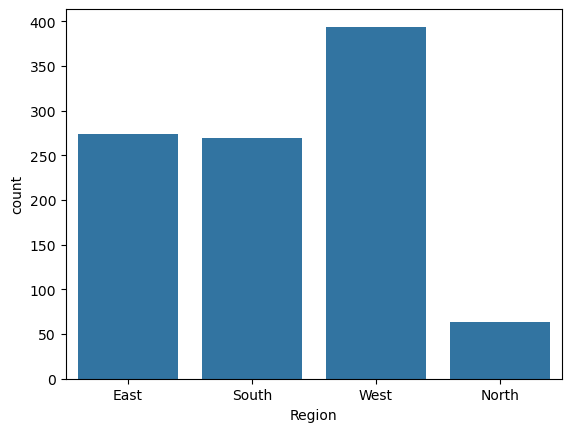

In [255]:
sns.countplot(x = df['Region'])

<Axes: xlabel='Location', ylabel='count'>

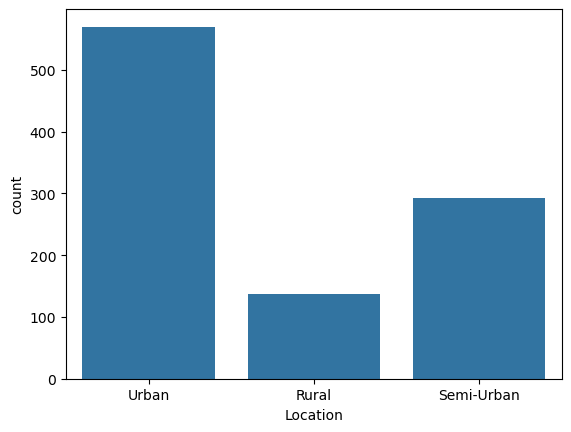

In [256]:
sns.countplot(x = df['Location'])

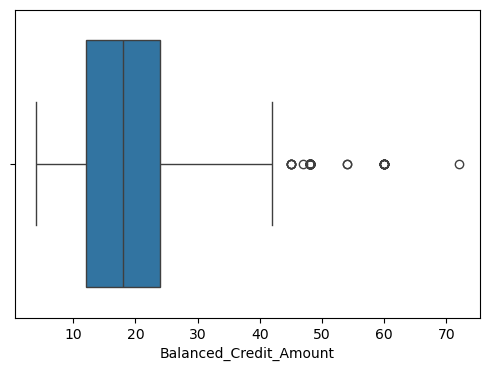

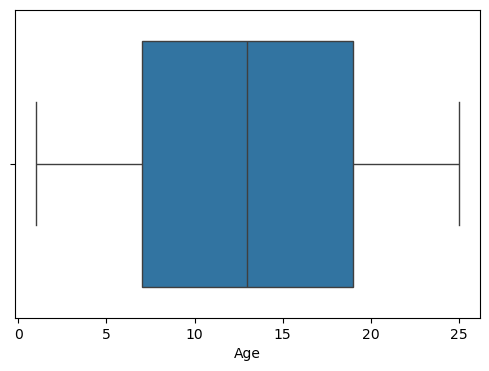

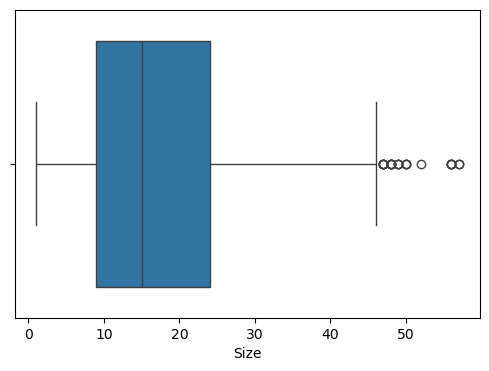

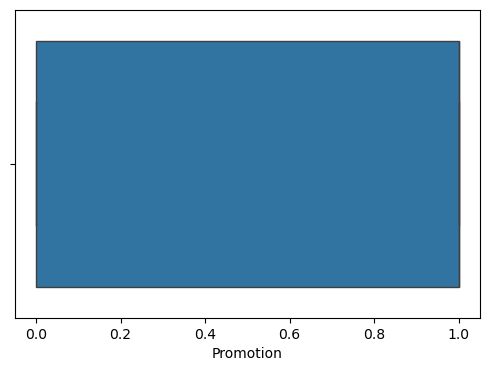

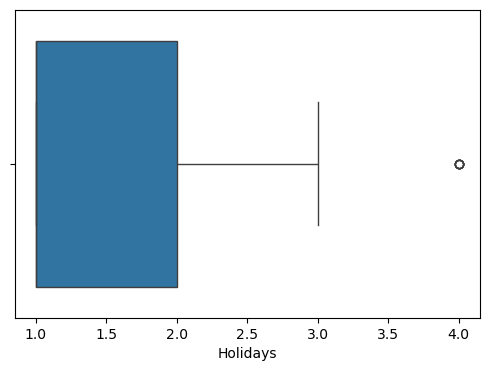

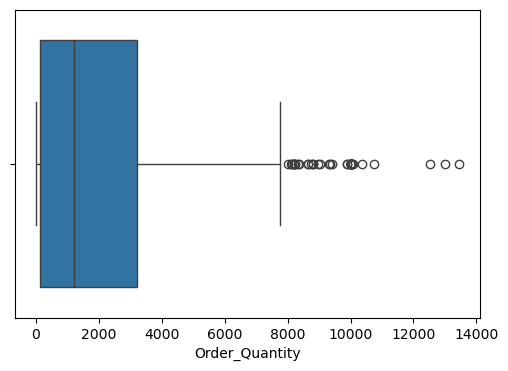

In [257]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

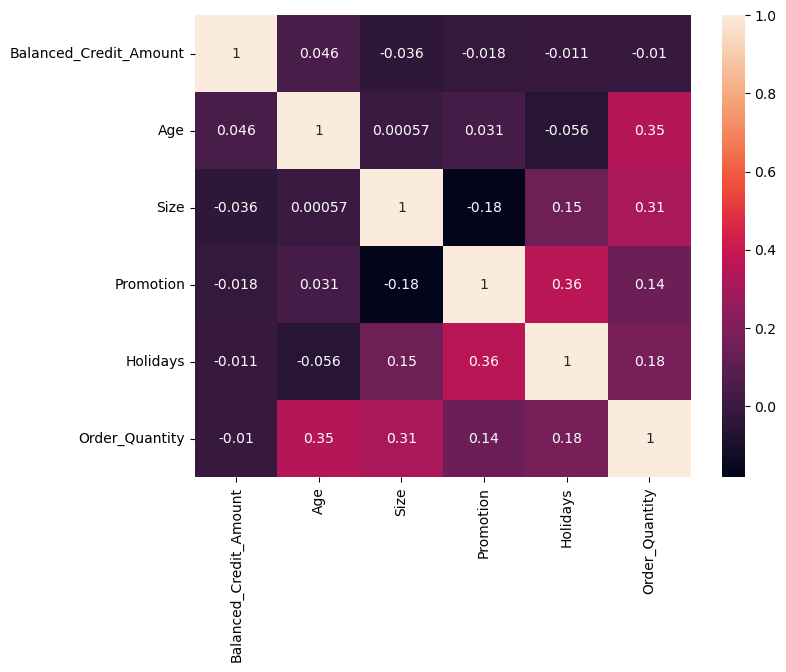

In [258]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and preprocessing

In [259]:
df_cleaned = df.copy()

In [260]:
df_cleaned.head()

,Region,Balanced_Credit_Amount,Location,Age,Size,Promotion,Holidays,Order_Quantity
0,East,12,Urban,6,2,0,1,0
1,East,12,Urban,3,2,0,1,0
2,East,24,Urban,5,2,0,1,0
3,South,24,Urban,18,2,0,1,0
4,South,45,Urban,21,3,0,1,0


In [261]:
df_cleaned.shape

(1000, 8)

In [262]:
df_cleaned.drop_duplicates(inplace = True)

In [263]:
df_cleaned.shape

(996, 8)

In [264]:
df_cleaned.isnull().sum()

Region                    0
Balanced_Credit_Amount    0
Location                  0
Age                       0
Size                      0
Promotion                 0
Holidays                  0
Order_Quantity            0
dtype: int64

In [265]:
df_cleaned.dtypes

Region                    object
Balanced_Credit_Amount     int64
Location                  object
Age                        int64
Size                       int64
Promotion                  int64
Holidays                   int64
Order_Quantity             int64
dtype: object

In [266]:
df_cleaned['Region'].value_counts()

Region
West     391
East     273
South    269
North     63
Name: count, dtype: int64

In [267]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['Region'],drop_first=True)

In [268]:
df_cleaned.head()

,Balanced_Credit_Amount,Location,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West
0,12,Urban,6,2,0,1,0,False,False,False
1,12,Urban,3,2,0,1,0,False,False,False
2,24,Urban,5,2,0,1,0,False,False,False
3,24,Urban,18,2,0,1,0,False,True,False
4,45,Urban,21,3,0,1,0,False,True,False


In [269]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['Location'],drop_first=True)

In [270]:
df_cleaned.head()

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban
0,12,6,2,0,1,0,False,False,False,False,True
1,12,3,2,0,1,0,False,False,False,False,True
2,24,5,2,0,1,0,False,False,False,False,True
3,24,18,2,0,1,0,False,True,False,False,True
4,45,21,3,0,1,0,False,True,False,False,True


In [271]:
df_cleaned = df_cleaned.astype(int)

In [272]:
df_cleaned

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban
0,12,6,2,0,1,0,0,0,0,0,1
1,12,3,2,0,1,0,0,0,0,0,1
2,24,5,2,0,1,0,0,0,0,0,1
3,24,18,2,0,1,0,0,1,0,0,1
4,45,21,3,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,16,15,50,1,3,7500,0,1,0,1,0
996,10,25,52,1,1,13000,0,1,0,0,1
997,9,1,56,1,1,0,0,1,0,0,0
998,6,4,56,1,3,2240,1,0,0,1,0


# Feature Engineering and Extraction

In [273]:
df_cleaned.columns

Index(['Balanced_Credit_Amount', 'Age', 'Size', 'Promotion', 'Holidays',
       'Order_Quantity', 'Region_North', 'Region_South', 'Region_West',
       'Location_Semi-Urban', 'Location_Urban'],
      dtype='object')

<Axes: xlabel='Size', ylabel='Count'>

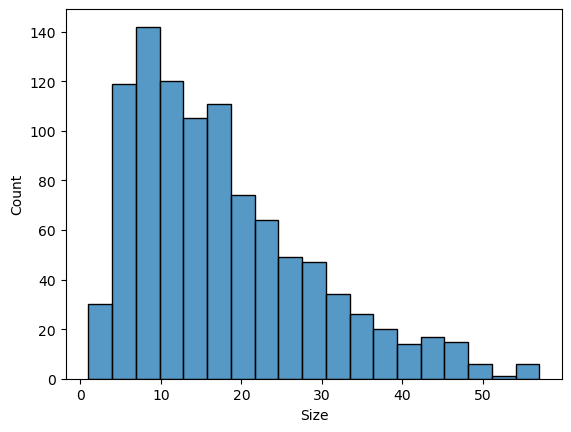

In [274]:
sns.histplot(df['Size'])

In [275]:
df_cleaned['Size_category'] = pd.cut(
    df_cleaned['Size'],
    bins=[-float('inf'), 10, 30, 50, float('inf')],
    labels=['Small', 'Medium', 'Large', 'Extra Large']
)

In [276]:
df_cleaned


,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban,Size_category
0,12,6,2,0,1,0,0,0,0,0,1,Small
1,12,3,2,0,1,0,0,0,0,0,1,Small
2,24,5,2,0,1,0,0,0,0,0,1,Small
3,24,18,2,0,1,0,0,1,0,0,1,Small
4,45,21,3,0,1,0,0,1,0,0,1,Small
...,...,...,...,...,...,...,...,...,...,...,...,...
995,16,15,50,1,3,7500,0,1,0,1,0,Large
996,10,25,52,1,1,13000,0,1,0,0,1,Extra Large
997,9,1,56,1,1,0,0,1,0,0,0,Extra Large
998,6,4,56,1,3,2240,1,0,0,1,0,Extra Large


In [277]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['Size_category'],drop_first=True)

In [278]:
df_cleaned


,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban,Size_category_Medium,Size_category_Large,Size_category_Extra Large
0,12,6,2,0,1,0,0,0,0,0,1,False,False,False
1,12,3,2,0,1,0,0,0,0,0,1,False,False,False
2,24,5,2,0,1,0,0,0,0,0,1,False,False,False
3,24,18,2,0,1,0,0,1,0,0,1,False,False,False
4,45,21,3,0,1,0,0,1,0,0,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,16,15,50,1,3,7500,0,1,0,1,0,False,True,False
996,10,25,52,1,1,13000,0,1,0,0,1,False,False,True
997,9,1,56,1,1,0,0,1,0,0,0,False,False,True
998,6,4,56,1,3,2240,1,0,0,1,0,False,False,True


In [279]:
df_cleaned = df_cleaned.astype(int)

In [280]:
df_cleaned

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban,Size_category_Medium,Size_category_Large,Size_category_Extra Large
0,12,6,2,0,1,0,0,0,0,0,1,0,0,0
1,12,3,2,0,1,0,0,0,0,0,1,0,0,0
2,24,5,2,0,1,0,0,0,0,0,1,0,0,0
3,24,18,2,0,1,0,0,1,0,0,1,0,0,0
4,45,21,3,0,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,16,15,50,1,3,7500,0,1,0,1,0,0,1,0
996,10,25,52,1,1,13000,0,1,0,0,1,0,0,1
997,9,1,56,1,1,0,0,1,0,0,0,0,0,1
998,6,4,56,1,3,2240,1,0,0,1,0,0,0,1


In [281]:
df_cleaned.columns

Index(['Balanced_Credit_Amount', 'Age', 'Size', 'Promotion', 'Holidays',
       'Order_Quantity', 'Region_North', 'Region_South', 'Region_West',
       'Location_Semi-Urban', 'Location_Urban', 'Size_category_Medium',
       'Size_category_Large', 'Size_category_Extra Large'],
      dtype='object')

In [282]:
from sklearn.preprocessing import StandardScaler
cols = ['Balanced_Credit_Amount', 'Age', 'Size', 'Holidays']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [283]:
df_cleaned

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_North,Region_South,Region_West,Location_Semi-Urban,Location_Urban,Size_category_Medium,Size_category_Large,Size_category_Extra Large
0,-0.738606,-0.975791,-1.369714,0,-0.703963,0,0,0,0,0,1,0,0,0
1,-0.738606,-1.393627,-1.369714,0,-0.703963,0,0,0,0,0,1,0,0,0
2,0.255630,-1.115069,-1.369714,0,-0.703963,0,0,0,0,0,1,0,0,0
3,0.255630,0.695555,-1.369714,0,-0.703963,0,0,1,0,0,1,0,0,0
4,1.995543,1.113391,-1.281817,0,-0.703963,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.407194,0.277719,2.849297,1,2.758490,7500,0,1,0,1,0,0,1,0
996,-0.904312,1.670506,3.025089,1,-0.703963,13000,0,1,0,0,1,0,0,1
997,-0.987165,-1.672184,3.376673,1,-0.703963,0,0,1,0,0,0,0,0,1
998,-1.235724,-1.254348,3.376673,1,2.758490,2240,1,0,0,1,0,0,0,1


# Correlation Table

In [284]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

target_col = 'Order_Quantity'

# List of features to check against target
selected_features = [
    'Balanced_Credit_Amount', 'Age', 'Size', 'Promotion', 'Holidays', 
    'Region_North', 'Region_South', 'Region_West', 
    'Location_Semi-Urban', 'Location_Urban', 'Size_category_Medium', 
    'Size_category_Large', 'Size_category_Extra Large'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned[target_col])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False)
correlation_df

,Feature,Pearson Correlation
1,Age,0.353351
11,Size_category_Large,0.317615
2,Size,0.309745
4,Holidays,0.176616
8,Location_Semi-Urban,0.172342
12,Size_category_Extra Large,0.145464
3,Promotion,0.141835
7,Region_West,0.047411
0,Balanced_Credit_Amount,-0.007894
5,Region_North,-0.022593


# Chi-Square Testing

In [285]:
cat_features = [
    'Promotion', 'Region_North', 'Region_South', 'Region_West',
    'Location_Semi-Urban', 'Location_Urban',
    'Size_category_Medium', 'Size_category_Large', 'Size_category_Extra Large'
]

In [286]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['Order_Quantity_Bins'] = pd.qcut(df_cleaned['Order_Quantity'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['Order_Quantity_Bins'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
Promotion,164.33231,0.0,Reject Null (Keep Feature)
Size_category_Large,146.982955,0.0,Reject Null (Keep Feature)
Region_West,75.067883,0.0,Reject Null (Keep Feature)
Location_Semi-Urban,55.827999,0.0,Reject Null (Keep Feature)
Size_category_Medium,42.295423,0.0,Reject Null (Keep Feature)
Location_Urban,33.120543,0.0,Reject Null (Keep Feature)
Region_South,11.481415,0.009388,Reject Null (Keep Feature)
Size_category_Extra Large,8.602418,0.035072,Reject Null (Keep Feature)
Region_North,3.717158,0.29367,Accept Null (Drop Feature)


In [287]:
final_df = df_cleaned[[
    'Balanced_Credit_Amount', 'Age', 'Size', 'Promotion', 'Holidays',
    'Order_Quantity', 'Region_South', 'Region_West', 
    'Location_Semi-Urban', 'Location_Urban', 'Size_category_Medium', 
    'Size_category_Large', 'Size_category_Extra Large'
]]

In [288]:
final_df

,Balanced_Credit_Amount,Age,Size,Promotion,Holidays,Order_Quantity,Region_South,Region_West,Location_Semi-Urban,Location_Urban,Size_category_Medium,Size_category_Large,Size_category_Extra Large
0,-0.738606,-0.975791,-1.369714,0,-0.703963,0,0,0,0,1,0,0,0
1,-0.738606,-1.393627,-1.369714,0,-0.703963,0,0,0,0,1,0,0,0
2,0.255630,-1.115069,-1.369714,0,-0.703963,0,0,0,0,1,0,0,0
3,0.255630,0.695555,-1.369714,0,-0.703963,0,1,0,0,1,0,0,0
4,1.995543,1.113391,-1.281817,0,-0.703963,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.407194,0.277719,2.849297,1,2.758490,7500,1,0,1,0,0,1,0
996,-0.904312,1.670506,3.025089,1,-0.703963,13000,1,0,0,1,0,0,1
997,-0.987165,-1.672184,3.376673,1,-0.703963,0,1,0,0,0,0,0,1
998,-1.235724,-1.254348,3.376673,1,2.758490,2240,0,0,1,0,0,0,1


# Random Forest Model

In [289]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [290]:
X = final_df.drop('Order_Quantity', axis=1)
y = final_df['Order_Quantity']

In [291]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training Rows: {X_train.shape[0]} | Testing Rows: {X_test.shape[0]}\n")

Training Rows: 796 | Testing Rows: 200



In [292]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [293]:
rf_model.score(X_test,y_test)

0.5798514409894112

In [294]:
n_train, p = X_train.shape[0], X_train.shape[1]
n_test = X_test.shape[0]

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

adj_train_r2 = 1 - ((1 - train_r2) * (n_train - 1) / (n_train - p - 1))
adj_test_r2 = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - p - 1))

# Output Print
print("="*40)
print("       MODEL PERFORMANCE METRICS")
print("="*40)
print(f"Train R² Score     : {train_r2:.4f}")
print(f"Train Adj R² Score : {adj_train_r2:.4f}")
print(f"Test R² Score      : {test_r2:.4f}")
print(f"Test Adj R² Score  : {adj_test_r2:.4f}")
print(f"MAE                : {mae:.2f}")
print(f"RMSE               : {rmse:.2f}")
print("="*40)

       MODEL PERFORMANCE METRICS
Train R² Score     : 0.8155
Train Adj R² Score : 0.8126
Test R² Score      : 0.5799
Test Adj R² Score  : 0.5529
MAE                : 1053.01
RMSE               : 1705.01


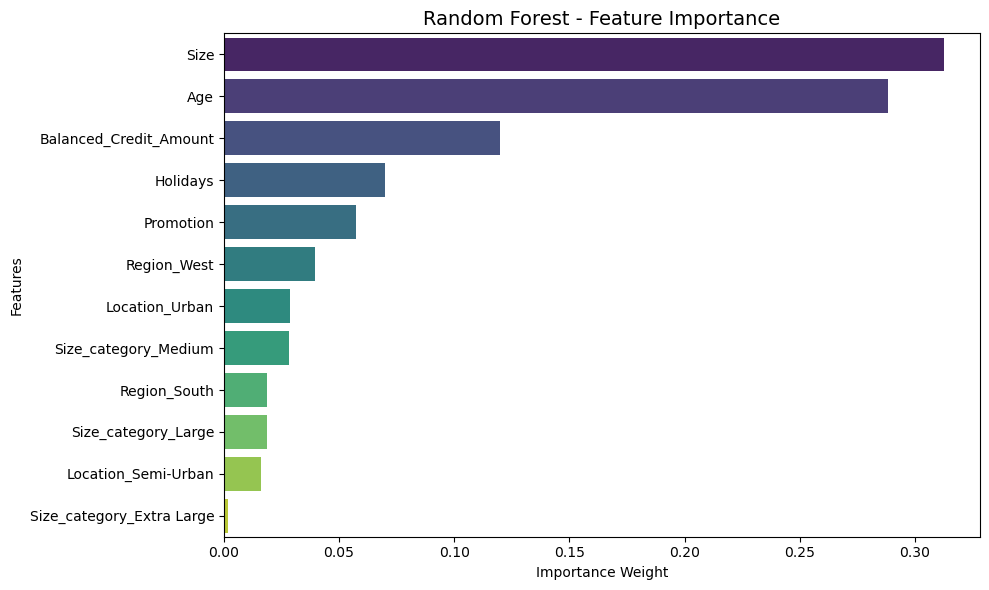

In [295]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Random Forest - Feature Importance', fontsize=14)
plt.xlabel('Importance Weight')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

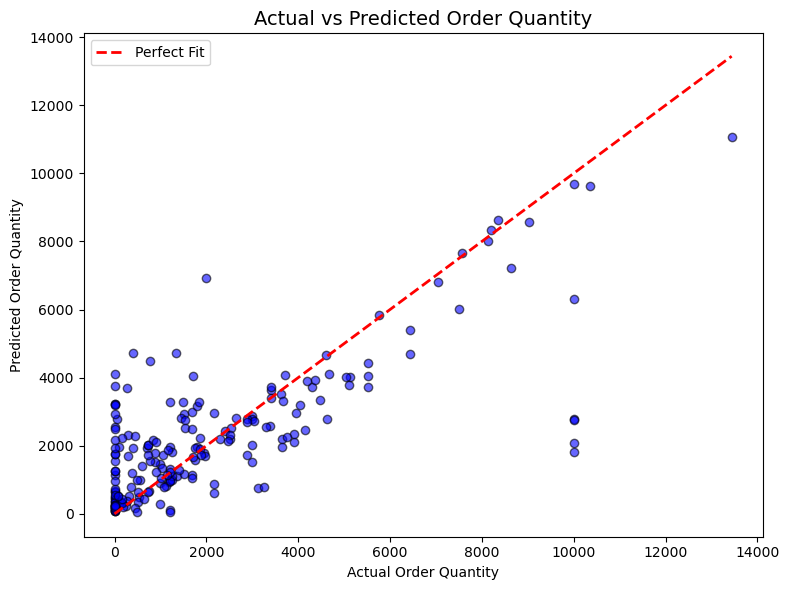

In [296]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Actual vs Predicted Order Quantity', fontsize=14)
plt.xlabel('Actual Order Quantity')
plt.ylabel('Predicted Order Quantity')
plt.legend()
plt.tight_layout()
plt.show()

In [297]:
sample_data = X_test.iloc[0:1]
pred_val = rf_model.predict(sample_data)[0]
print(f"Sample Predicted Value: {pred_val:.2f}")

Sample Predicted Value: 268.26
